In [12]:
# !pip install torch torchvision matplotlib scikit-learn

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from pathlib import Path

In [14]:
DATA_DIR = Path("/var/my-data/datasets/zenodo-8041387/data")
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 7
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

Using device: cuda


In [15]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

In [16]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class ScreenshotDataset(Dataset):

    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples = []

        for label, class_name in enumerate(["not-phishing", "phishing"]):
            files = Path(root).glob(f"{class_name}/*/screenshots/*.jpg")
            for p in files:
                self.samples.append((p, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

In [17]:
from pathlib import Path
from torch.utils.data import random_split

dataset = ScreenshotDataset(DATA_DIR, transform=transform)

val_ratio = 0.2
n_total = len(dataset)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(dataset, [n_train, n_val], generator=generator)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
)

In [18]:
count_legit = sum(1 for sample in dataset.samples if sample[1] == 0)
count_phish = sum(1 for sample in dataset.samples if sample[1] == 1)
print(count_legit, count_phish)

6000 6000


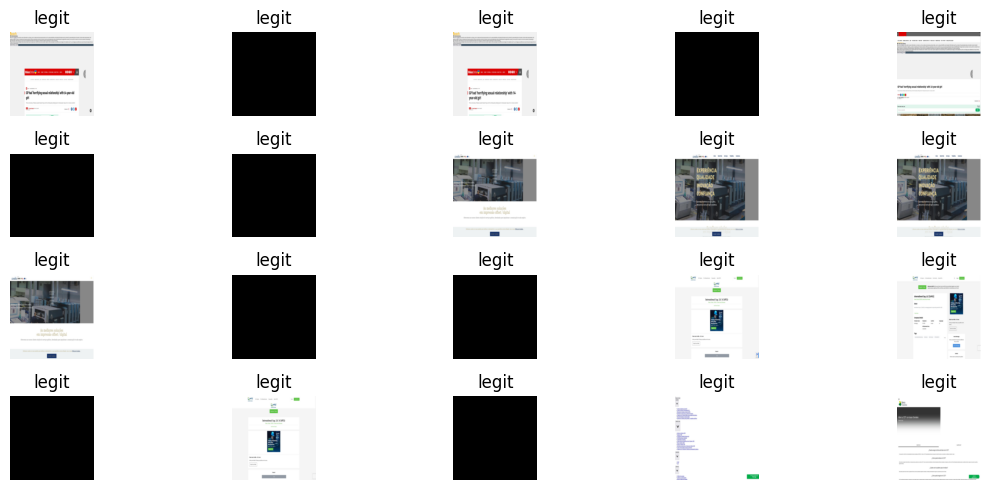

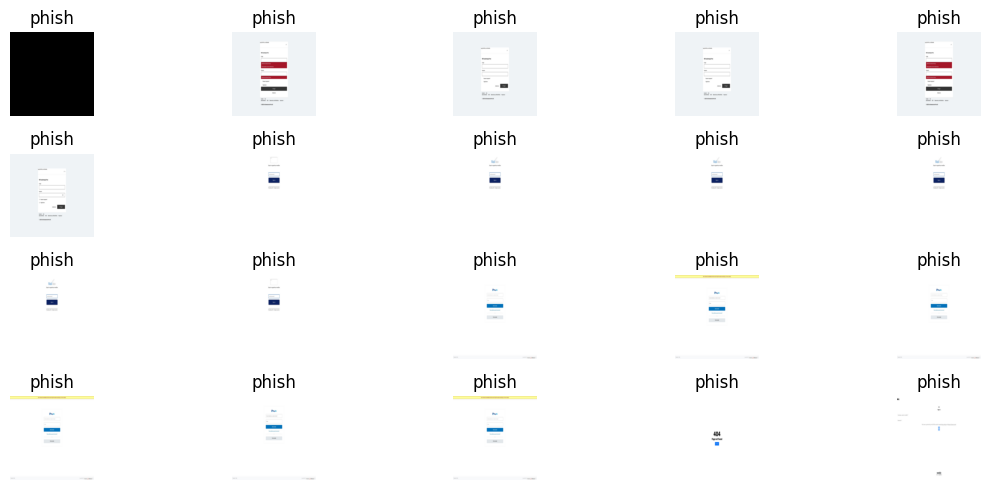

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img, label = dataset[i]

    ax.imshow(img.permute(1, 2, 0))
    ax.set_title("phish" if label else "legit")
    ax.axis("off")

plt.tight_layout()
plt.show()
fig, axes = plt.subplots(4, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img, label = dataset[len(dataset) - 1 - i]

    ax.imshow(img.permute(1, 2, 0))
    ax.set_title("phish" if label else "legit")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [20]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * (IMAGE_SIZE//4) * (IMAGE_SIZE//4), 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [21]:
model = SimpleCNN(num_classes=2).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)

In [22]:
from tqdm.notebook import tqdm

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for X, y in pbar:

        X = X.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(X)

        loss = criterion(outputs, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        pbar.set_postfix(loss=total_loss / (pbar.n + 1))

    train_loss = total_loss / len(train_loader)

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X, y in val_loader:

            X = X.to(DEVICE)
            y = y.to(DEVICE)

            outputs = model(X)

            loss = criterion(outputs, y)

            val_loss += loss.item()

            preds = outputs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"train_loss: {train_loss:.4f}")
    print(f"val_loss:   {val_loss:.4f}")
    print(f"val_acc:    {val_acc:.4f}")

Epoch 1/7:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/7
train_loss: 0.5431
val_loss:   0.4171
val_acc:    0.8108


Epoch 2/7:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 2/7
train_loss: 0.3581
val_loss:   0.3132
val_acc:    0.8700


Epoch 3/7:   0%|          | 0/300 [00:00<?, ?it/s]

...

Epoch 5/7
train_loss: 0.1531
val_loss:   0.2070
val_acc:    0.9250


Epoch 6/7:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 6/7
train_loss: 0.1188
val_loss:   0.1993
val_acc:    0.9275


Epoch 7/7:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 7/7
train_loss: 0.1095
val_loss:   0.1972
val_acc:    0.9329


In [24]:
torch.save(model.state_dict(), "../models/img_clf_model.pt")

In [29]:
from PIL import Image

def predict_image(path):

    img = Image.open(path).convert("RGB")
    img = transform(img).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        out = model(img)
        pred = out.argmax(1).item()

    return pred


print(predict_image("/var/my-data/datasets/zenodo-8041387/data/not-phishing/642ea9b761bb656e3eb3ee0f/screenshots/clean_js_off.jpg"))
print(predict_image("/var/my-data/datasets/zenodo-8041387/data/not-phishing/643ff85555cc7ad2f739c5a8/screenshots/clean_js_off.jpg"))
print(predict_image("/var/my-data/datasets/zenodo-8041387/data/phishing/640a34885e12d83aeab23d8c/screenshots/clean_js_off.jpg"))

0
0
1
